In [ ]:
import torch 
import torchopt
import numpy as np
from torch import nn
import torch.optim as optim
import matplotlib.pyplot as plt



class NNApproximator(nn.Module):
    def __init__(self, num_inputs: int = 2, num_outputs: int = 2, num_hidden: int = 1, dim_hidden: int = 1,
        act: nn.Module = nn.Tanh(),) -> None:
        """Simple neural network with linear layers and non-linear activation function
        This class is used as universal function approximator for the solution of
        partial differential equations using PINNs
        Args:
            num_inputs (int, optional): The number of input dimensions
            num_outputs (int, optional): The number of outputs of the model, in general is 1
            num_hidden (int, optional): The number of hidden layers in the model
            dim_hidden (int, optional): The number of neurons for each hidden layer
            act (nn.Module, optional): The type of non-linear activation function to be used
        """
        super().__init__()


        self.layer_in = nn.Linear(num_inputs, dim_hidden)
        self.layer_out = nn.Linear(dim_hidden, num_outputs)


        num_middle = num_hidden - 1
        self.middle_layers = nn.ModuleList(
            [nn.Linear(dim_hidden, dim_hidden) for _ in range(num_middle)])
        #print(self.middle_layers)
        self.act = act

        self.num_inputs = num_inputs
        self.num_outputs = num_outputs

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        out = self.act(self.layer_in(x))
        for layer in self.middle_layers:
            out = self.act(layer(out))
        return self.layer_out(out)


In [ ]:
# create the PINN model and make it functional using functorch utilities
model = NNApproximator()
params = dict(model.named_parameters())

def apply_model(x):
    return model(x.unsqueeze(0)).squeeze(0)
# use `vmap` primitive to allow efficient batching of the input
model_v = torch.vmap(apply_model)
#print(model_v(x))
diff_model = torch.func.grad(apply_model)
diff_model_v = torch.vmap(diff_model)
diff_diff_model = torch.func.grad(diff_model)
diff_diff_model_v = torch.vmap(diff_diff_model)


In [ ]:
import torch
import torch.nn as nn

R = 1.0  # rate of maximum population growth parameterizing the equation
X_BOUNDARY = 0.0  # boundary condition coordinate
F_BOUNDARY = 0.5  # boundary condition value


def loss_fn(params: torch.Tensor, x: torch.Tensor, model_v) -> torch.Tensor:

    # interior loss
    f_value = model_v(x)
    interior = diff_model_v(x) - R * f_value * (1 - f_value)
    #print(interior)

    # boundary loss
    x0 = X_BOUNDARY
    f0 = F_BOUNDARY
    x_boundary = torch.tensor([x0])
    f_boundary = torch.tensor([f0])
    boundary = model_v(x_boundary) - f_boundary

    loss = nn.MSELoss()
    loss_value = loss(interior, torch.zeros_like(interior)) + loss(
        boundary, torch.zeros_like(boundary)
    
    )

    return loss_value

#print("loss_fn", loss_fn(params, x))

In [ ]:
# choose the configuration
batch_size = 30  # number of colocation points sampled in the domain
num_iter = 1000  # maximum number of iterations
learning_rate = 1e-3  # learning rate
domain = (-5.0, 5.0)  # logistic equation domain

# choose optimizer with functional API using functorch


# Initialisieren Sie eine Liste, um die Verlustwerte im Laufe des Trainings zu speichern
loss_evolution = []

# train the model
for i in range(num_iter):

    # sample colocations points in the domain randomly at each epoch
    x = torch.FloatTensor(batch_size).uniform_(domain[0], domain[1])
    #output = model_v(x)
    optimizer = optim.Adam(model.parameters(), lr=1e-3)
    # update the parameters using the functional API
    loss = loss_fn(params, x, model_v)
    optimizer.zero_grad()
    loss.backward()
    #Performs a single optimization step
    optimizer.step()
    
    
    # Speichern Sie den aktuellen Verlustwert in der Verlustverlaufshistorie
    loss_evolution.append(float(loss))

    print(f"Iteration {i} with loss {float(loss)}")


In [ ]:
# creates list, with entries between 0 and 1 in 100 steps. 
# reshape brings it in form of a vector 
# -1 => the vector has as many rows as entries
# 1 => the vector has one column
x_eval = torch.linspace(domain[0], domain[1], steps=100).reshape(-1, 1)

# evaluates the function values to the given x values
f_eval = model_v(x_eval).squeeze()

# creates a analytical solution for comparison purposes
analytical_sol_fn = lambda x: 1.0 / (1.0 + (1.0/F_BOUNDARY - 1.0) * np.exp(-R * x))

# creates a numpy array from x_eval and detaches it from x_eval
x_eval_np = x_eval.detach().numpy()

# creates an numpy array with the x values of the sample points
x_sample_np = torch.FloatTensor(batch_size).uniform_(domain[0], domain[1]).detach().numpy()

#creates Figures and axes for the first plot

fig, ax = plt.subplots()

# creates a scatter plot of the Sample training points
ax.scatter(x_sample_np, analytical_sol_fn(x_sample_np), color="red", label="Sample training points")
# ads the PINN solution, analytical solution, title and legend to the plot
ax.plot(x_eval_np, f_eval.detach().numpy(), label="PINN final solution")
ax.plot(
    x_eval_np,
    analytical_sol_fn(x_eval_np),
    label=f"Analytic solution",
    color="green",
    alpha=0.75,
)
ax.set(title="Logistic equation solved with NNs", xlabel="t", ylabel="f(t)")
ax.legend()

#creates Figures and axes for the second plot
fig, ax = plt.subplots()
ax.semilogy(loss_evolution) #y-axis is logarithmic
ax.set(title="Loss evolution", xlabel="# epochs", ylabel="Loss")


plt.show()

# Data Generation

[[  0.          40.           0.          60.        ]
 [  0.39590631  39.18698245   0.5933723   58.68337045]
 [  0.78385054  38.40724045   1.17384011  57.41856542]
 ...
 [ 57.42350875   0.23811987 -82.8110057  -18.44520165]
 [ 57.42588364   0.23685871 -82.99545846 -18.44535033]
 [ 57.42824594   0.23560423 -83.1799127  -18.44549753]]
[[ 0.00000000e+00  4.00000000e+01  0.00000000e+00  6.00000000e+01
  -8.30358459e+01 -1.34363769e+02]
 [ 3.95906307e-01  3.91869825e+01  5.93372300e-01  5.86833705e+01
  -7.96035489e+01 -1.29018070e+02]
 [ 7.83850538e-01  3.84072405e+01  1.17384011e+00  5.74185654e+01
  -7.63778847e+01 -1.23994423e+02]
 ...
 [ 5.74235087e+01  2.38119869e-01 -8.28110057e+01 -1.84452016e+01
  -1.26450100e-01 -1.49433532e-02]
 [ 5.74258836e+01  2.36858715e-01 -8.29954585e+01 -1.84453503e+01
  -1.25781286e-01 -1.47940722e-02]
 [ 5.74282459e+01  2.35604231e-01 -8.31799127e+01 -1.84454975e+01
  -1.25115995e-01 -1.46462764e-02]]


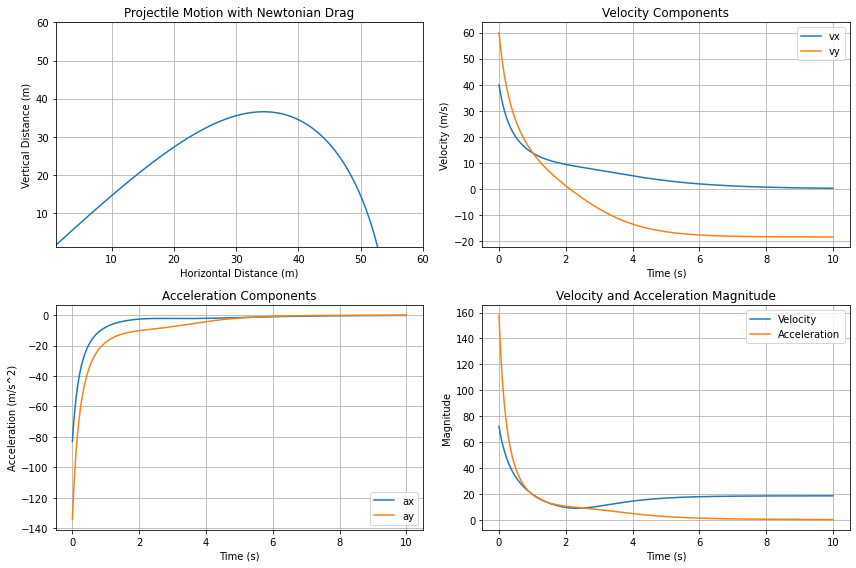

In [1]:
import numpy as np
import matplotlib.pyplot as plt

g = 9.81  # Acceleration due to gravity (m/s^2)
rho = 1.225  # Air density (kg/m^3)
Cd = 0.47  # Drag coefficient
A = 0.01  # Cross-sectional area (m^2)
m = 0.1  # Mass of the projectile (kg)

def runge_kutta_4th_order(f, x0, y0, h, n):
    x_vals = [x0]
    y_vals = [y0]
    for _ in range(n):
        k1 = h * f(x_vals[-1], y_vals[-1])
        k2 = h * f(x_vals[-1] + h / 2, y_vals[-1] + k1 / 2)
        k3 = h * f(x_vals[-1] + h / 2, y_vals[-1] + k2 / 2)
        k4 = h * f(x_vals[-1] + h, y_vals[-1] + k3)

        x_vals.append(x_vals[-1] + h)
        y_vals.append(y_vals[-1] + (k1 + 2 * k2 + 2 * k3 + k4) / 6)
    return np.array(x_vals), np.array(y_vals)

def projectile_motion_with_drag(t, u):
    x, vx, y, vy = u
    g = 9.81  # Acceleration due to gravity (m/s^2)
    rho = 1.225  # Air density (kg/m^3)
    Cd = 0.47  # Drag coefficient
    A = 0.01  # Cross-sectional area (m^2)
    m = 0.1  # Mass of the projectile (kg)

    v = np.sqrt(vx**2 + vy**2)
    Fx = -0.5 * rho * Cd * A * v * vx
    Fy = -0.5 * rho * Cd * A * v * vy

    dxdt = vx
    dvxdt = (Fx / m)
    dydt = vy
    dvydt = (Fy / m) - g

    return np.array([dxdt, dvxdt, dydt, dvydt])

# Initial conditions
x0 = 0.0
y0 = 0.0
vx0 = 40.0
vy0 = 60.0

u0 = np.array([x0, vx0, y0, vy0])

# Time settings
t0 = 0.0
h = 0.01  # Step size
num_steps = 1000

# Solve the system of ODEs using Runge-Kutta 4th order
time_vals, state_vals = runge_kutta_4th_order(projectile_motion_with_drag, t0, u0, h, num_steps)
print(state_vals)
# Extract position, velocity, and acceleration values
x_vals = state_vals[:, 0]
vx_vals = state_vals[:, 1]
y_vals = state_vals[:, 2]
vy_vals = state_vals[:, 3]

# Calculate acceleration components ax and ay
ax_vals = (-0.5 * rho * Cd * A * vx_vals * np.sqrt(vx_vals**2 + vy_vals**2)) / m
ay_vals = (-0.5 * rho * Cd * A * vy_vals * np.sqrt(vx_vals**2 + vy_vals**2)) / m - g


# Concatenate the new columns to the original array
state_vals_2 = np.concatenate((state_vals, ax_vals[:, np.newaxis], ay_vals[:, np.newaxis]), axis=1)
print(state_vals_2)

# Calculate velocity magnitude v
v_vals = np.sqrt(vx_vals**2 + vy_vals**2)

# Calculate acceleration magnitude a
a_vals = np.sqrt(ax_vals**2 + ay_vals**2)

# Plot the trajectory, velocity, and acceleration
plt.figure(figsize=(12, 8))

plt.subplot(2, 2, 1)
plt.plot(x_vals, y_vals)
plt.title("Projectile Motion with Newtonian Drag")
plt.xlabel("Horizontal Distance (m)")
plt.ylabel("Vertical Distance (m)")
plt.xlim(1, 60)
plt.ylim(1, 60)
plt.grid(True)

plt.subplot(2, 2, 2)
plt.plot(time_vals, vx_vals, label='vx')
plt.plot(time_vals, vy_vals, label='vy')
plt.title("Velocity Components")
plt.xlabel("Time (s)")
plt.ylabel("Velocity (m/s)")
plt.legend()
plt.grid(True)

plt.subplot(2, 2, 3)
plt.plot(time_vals, state_vals_2[:, 4], label='ax')
plt.plot(time_vals, ay_vals, label='ay')
plt.title("Acceleration Components")
plt.xlabel("Time (s)")
plt.ylabel("Acceleration (m/s^2)")
plt.legend()
plt.grid(True)

plt.subplot(2, 2, 4)
plt.plot(time_vals, v_vals, label='Velocity')
plt.plot(time_vals, a_vals, label='Acceleration')
plt.title("Velocity and Acceleration Magnitude")
plt.xlabel("Time (s)")
plt.ylabel("Magnitude")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


# model initialisation

In [2]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

# Generate data using the provided Runge-Kutta solver
# ... (Your data generation code here)

# Convert numpy arrays to PyTorch tensors
x_data = torch.tensor(time_vals, dtype=torch.float32).view(-1, 1).requires_grad_(True)
y_data = torch.tensor(state_vals_2, dtype=torch.float32)  

# Define the Physics-Informed Neural Network (PINN) architecture
class NNApproximator(nn.Module):
    def __init__(self):
        super(NNApproximator, self).__init__()
        self.fc1 = nn.Linear(1, 30)
        self.fc2 = nn.Linear(30, 30)
        self.fc3 = nn.Linear(30, 4)  # Predict x and y

    def forward(self, x):
        x = torch.relu(self.fc1(x))
        x = torch.relu(self.fc2(x))
        x = self.fc3(x)
        return x

# Instantiate the PINN model
model = NNApproximator()
params = dict(model.named_parameters())
optimizer = optim.Adam(model.parameters(), lr=0.001)

# vmapping


In [3]:
x = model(x_data)[:,0]
y = model(x_data)[:,1]
#x_grad = torch.autograd.grad(x, inputs=x_data, create_graph=True)
# Define a function that applies the model to an input vector 
# using the squeeze method to get x into the right form
def apply_model(x_data):
    
    return model(x_data.unsqueeze(0)).squeeze(0)
print('apply_model: ',apply_model)
x_v = torch.vmap(model(x_data.unsqueeze(0)).squeeze(0)[:,0])
y_v = torch.vmap(model(x_data.unsqueeze(0)).squeeze(0)[:,1])
print('x_v: ', x_v)
#x_v_grad = torch.autograd.grad(x_v, inputs=x_data, create_graph=True)

#dxdt=  torch.autograd.grad(apply_model(x_data)[0], x_data, create_graph=True)[0]

# Apply the model to the input using vmap
model_v = torch.vmap(apply_model)
print('model_v: ', model_v)

diff_model_x= torch.func.grad(model(x_data.unsqueeze(0)).squeeze(0)[:,0])
diff_model_y= torch.func.grad(model(x_data.unsqueeze(0)).squeeze(0)[:,1])
diff_diff_model_x= torch.func.grad(diff_model_x)
diff_diff_model_y= torch.func.grad(diff_model_y)
diff_model_x_v= torch.vmap(diff_model_x)
diff_model_y_v= torch.vmap(diff_model_y)
diff_diff_model_x_v=torch.vmap(diff_diff_model_x)
diff_diff_model_y_v=torch.vmap(diff_diff_model_y)


# computing its derivative using grad 
# important: first apply grad and then use the vmap. You can only grad scalar functions.
diff_model= torch.func.grad(apply_model)
diff_model_v= torch.vmap(diff_model)
diff_diff_model= torch.func.grad(diff_model)
diff_diff_model_v= torch.vmap(diff_diff_model)
print('diff_diff_model_x_v: ',diff_diff_model_x_v)
print(diff_model)

apply_model:  <function apply_model at 0x000002CCE6461820>
x_v:  <function vmap.<locals>.wrapped at 0x000002CCE40254C0>
model_v:  <function apply_model at 0x000002CCEE363CA0>
diff_diff_model_x_v:  <function grad.<locals>.wrapper at 0x000002CCEE3639D0>
<function apply_model at 0x000002CCEE3750D0>


In [4]:
# Initialize empty tensors to store derivatives
d2x_dx2_tensor = torch.empty((len(x_data), 1))  # Second partial derivative of x with respect to x
d2y_dx2_tensor = torch.empty((len(x_data), 1))  # Second partial derivative of y with respect to x

# Loop through each entry in x_data and compute second partial derivatives
for i, x_entry in enumerate(x_data):
    # Compute first derivative of apply_model(x_entry)[0] with respect to x_entry
    first_derivative_x = torch.autograd.grad(apply_model(x_entry)[0], x_entry, create_graph=True)[0]

    # Compute second derivative of apply_model(x_entry)[0] with respect to x_entry
    d2x_dx2_entry = torch.autograd.grad(first_derivative_x, x_entry, create_graph=True)[0]

    # Compute first derivative of apply_model(x_entry)[1] with respect to x_entry
    first_derivative_y = torch.autograd.grad(apply_model(x_entry)[1], x_entry, create_graph=True)[0]

    # Compute second derivative of apply_model(x_entry)[1] with respect to x_entry
    d2y_dx2_entry = torch.autograd.grad(first_derivative_y, x_entry, create_graph=True)[0]

    # Store the calculated derivatives in the respective tensors
    d2x_dx2_tensor[i] = d2x_dx2_entry
    d2y_dx2_tensor[i] = d2y_dx2_entry


# Loss function

In [5]:
# Define the PINN loss function
def pinn_loss(model_v, x_data, y_data):
    
    # Predict all components using the PINN model
    predicted_values = model_v(x_data)
    dx_dt = torch.autograd.grad(predicted_values[:, 0].sum(), x_data, create_graph=True)[0]
    dy_dt = torch.autograd.grad(predicted_values[:, 1].sum(), x_data, create_graph=True)[0]
    d2x_dt2 = torch.autograd.grad(dx_dt.sum(), x_data, create_graph=True)[0]
    d2y_dt2 = torch.autograd.grad(dy_dt.sum(), x_data, create_graph=True)[0]
    
    # Extract predicted components
    predicted_x = predicted_values[:, 0]
    predicted_y = predicted_values[:, 1]
    #predicted_vx = predicted_values[:, 2]
    #predicted_vy = predicted_values[:, 3]
    predicted_ax = predicted_values[:, 2]
    predicted_ay = predicted_values[:, 3]
    
    # Calculate the data fitting loss terms for each component
    loss_x = nn.MSELoss()(predicted_x, y_data[:, 0])
    loss_y = nn.MSELoss()(predicted_y, y_data[:, 2])
    #loss_vx = nn.MSELoss()(predicted_vx, y_data[:, 1])
    #loss_vy = nn.MSELoss()(predicted_vy, y_data[:, 3])
    loss_ax = nn.MSELoss()(predicted_ax, y_data[:, 4])
    loss_ay = nn.MSELoss()(predicted_ay, y_data[:, 5])
    
    '''
    # Calculate the physics-informed loss terms for acceleration (ax, ay)
    loss_physics_ax = nn.MSELoss()(predicted_ax, (-0.5 * rho * Cd * A * y_data[: , 1] * torch.sqrt(y_data[: , 1]**2 + y_data[: , 3]**2)) / m)
    loss_physics_ay = nn.MSELoss()(predicted_ay, ((-0.5 * rho * Cd * A * y_data[: , 3] * torch.sqrt(y_data[: , 1]**2 + y_data[: , 3]**2)) / m) - g)
    '''
    #y_data = y_data.view(-1, 1)
    # Calculate the physics-informed loss terms for acceleration (ax, ay)
    loss_physics_ax = nn.MSELoss()(d2x_dt2, (-0.5 * rho * Cd * A * y_data[: , 1] * torch.sqrt(y_data[: , 1]**2 + y_data[: , 3]**2)) / m)
    loss_physics_ay = nn.MSELoss()(d2y_dt2, ((-0.5 * rho * Cd * A * y_data[: , 3] * torch.sqrt(y_data[: , 1]**2 + y_data[: , 3]**2)) / m) - g)
    
    # Combine all loss terms (data fitting and physics-informed)
    total_loss = loss_x + loss_y + loss_ax + loss_ay + loss_physics_ax + loss_physics_ay #+ loss_vx + loss_vy 
    
    return total_loss


# Training loop

In [6]:

# Training loop
num_epochs = 10000
for epoch in range(num_epochs):
    # Zero the gradients
    optimizer.zero_grad()
    
    # Forward pass
    outputs = model_v(x_data)
    
    # Compute the loss
    loss = pinn_loss(model_v, x_data, y_data)
    
    # Backpropagation and optimization
    loss.backward()
    optimizer.step()
    
    if (epoch + 1) % 1000 == 0:
        print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {loss.item():.4f}')

# Generate predictions using the trained PINN model
x_pred = torch.linspace(0, max(time_vals), 1000).view(-1, 1)
with torch.no_grad():
    y_pred = model_v(x_data)

C:\Users\Lorenz\anaconda3\lib\site-packages\torch\nn\modules\loss.py:536: UserWarning: Using a target size (torch.Size([1001])) that is different to the input size (torch.Size([1001, 1])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)


Epoch [1000/10000], Loss: 660.1798
Epoch [2000/10000], Loss: 486.5865
Epoch [3000/10000], Loss: 459.8072
Epoch [4000/10000], Loss: 449.3240
Epoch [5000/10000], Loss: 445.7841
Epoch [6000/10000], Loss: 444.6164
Epoch [7000/10000], Loss: 444.1399
Epoch [8000/10000], Loss: 443.9181
Epoch [9000/10000], Loss: 443.7925
Epoch [10000/10000], Loss: 443.7032


# Plot

In [ ]:
# Plot the trajectory and PINN predictions
plt.figure(figsize=(8, 6))
plt.plot(x_vals, y_vals, label='Actual Trajectory')
plt.plot(x_pred, y_pred[:, 0], label='PINN Predictions')
plt.title("Projectile Motion with Newtonian Drag (PINN)")
plt.xlabel("Horizontal Distance (m)")
plt.ylabel("Vertical Distance (m)")
plt.xlim(1, 60)
plt.ylim(1, 60)
plt.legend()
plt.grid(True)
plt.show()

# Network prediction


In [7]:
# Predict all components using the PINN model
predicted_values = model_v(x_data)

# Extract predicted components
predicted_x = predicted_values[:, 0].detach().numpy()
predicted_y = predicted_values[:, 1].detach().numpy()
#predicted_vx = predicted_values[:, 2].detach().numpy()
#predicted_vy = predicted_values[:, 3].detach().numpy()
predicted_ax = predicted_values[:, 2].detach().numpy()
predicted_ay = predicted_values[:, 3].detach().numpy()

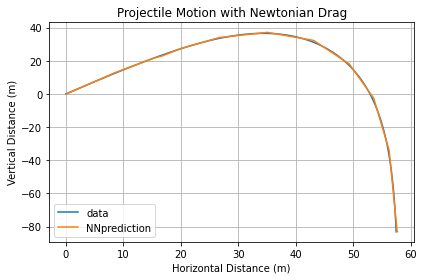

In [8]:
#plt.subplot(2, 2, 1)
plt.plot(x_vals, y_vals, label='data')
plt.plot(predicted_x, predicted_y, label='NNprediction')
plt.title("Projectile Motion with Newtonian Drag")
plt.xlabel("Horizontal Distance (m)")
plt.ylabel("Vertical Distance (m)")
plt.legend()
#plt.xlim(1, 60)
#plt.ylim(1, 60)
plt.grid(True)

'''
plt.subplot(2, 2, 2)
plt.plot(time_vals, vx_vals, label='vx')
plt.plot(time_vals, vy_vals, label='vy')
plt.title("Velocity Components")
plt.xlabel("Time (s)")
plt.ylabel("Velocity (m/s)")
plt.legend()
plt.grid(True)

plt.subplot(2, 2, 3)
plt.plot(time_vals, state_vals_2[:, 4], label='ax')
plt.plot(time_vals, ay_vals, label='ay')
plt.title("Acceleration Components")
plt.xlabel("Time (s)")
plt.ylabel("Acceleration (m/s^2)")
plt.legend()
plt.grid(True)

plt.subplot(2, 2, 4)
plt.plot(time_vals, v_vals, label='Velocity')
plt.plot(time_vals, a_vals, label='Acceleration')
plt.title("Velocity and Acceleration Magnitude")
plt.xlabel("Time (s)")
plt.ylabel("Magnitude")
plt.legend()
plt.grid(True)
'''
plt.tight_layout()
plt.show()
